In [101]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import os

## Aditional function


In [2]:
def show_bgr_pair(
    original,
    corrected,
    original_title="Original",
    corrected_title="Corrected",
    max_width=1200
):
    """
    Display original and corrected BGR images in one figure.
    """

    def resize_for_display(img):
        height, width = img.shape[:2]
        scale = min(1.0, max_width / width)

        if scale < 1.0:
            img = cv2.resize(
                img,
                (
                    int(width * scale),
                    int(height * scale)
                ),
                interpolation=cv2.INTER_AREA
            )

        return img

    original_display = resize_for_display(original)
    corrected_display = resize_for_display(corrected)

    original_rgb = cv2.cvtColor(
        original_display,
        cv2.COLOR_BGR2RGB
    )

    corrected_rgb = cv2.cvtColor(
        corrected_display,
        cv2.COLOR_BGR2RGB
    )

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(18, 10)
    )

    axes[0].imshow(original_rgb)
    axes[0].set_title(original_title)
    axes[0].axis("off")

    axes[1].imshow(corrected_rgb)
    axes[1].set_title(corrected_title)
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

# Gausiian blur


## Settings

In [84]:
# --------------------------------------------------
# File paths
# --------------------------------------------------
input_path = Path.cwd().parent / "full_view" / "Balbc_10x_2k.jpg"
output_path = Path.cwd().parent / "full_view" / "Balbc_10x_2k_corrected.png"

In [85]:
# --------------------------------------------------
# Settings
# --------------------------------------------------
background_blur = 501
correction_strength = 0.5



## Working_body

In [93]:
# --------------------------------------------------
# Load image using Pillow
# --------------------------------------------------
with Image.open(input_path) as pil_image:
    rgb_image = pil_image.convert("RGB")

# Convert Pillow RGB image to OpenCV BGR format
rgb = np.array(rgb_image)
bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)

print("Image loaded:", bgr.shape)

Image loaded: (4306, 1772, 3)


In [ ]:
# --------------------------------------------------
# Create a tissue mask
# --------------------------------------------------
hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)

saturation = hsv[:, :, 1]
value = hsv[:, :, 2]

# Tissue is usually more saturated than the gray checkerboard background
tissue_mask = ((saturation > 18) & (value < 250)).astype(np.uint8) * 255

kernel = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (25, 25)
)

tissue_mask = cv2.morphologyEx(
    tissue_mask,
    cv2.MORPH_CLOSE,
    kernel
)

tissue_mask = cv2.morphologyEx(
    tissue_mask,
    cv2.MORPH_OPEN,
    kernel
)

tissue_mask = cv2.dilate(
    tissue_mask,
    np.ones((9, 9), np.uint8)
)

In [95]:
# --------------------------------------------------
# Convert to Lab color space
# --------------------------------------------------
lab = cv2.cvtColor(bgr, cv2.COLOR_BGR2LAB)

lightness, a_channel, b_channel = cv2.split(lab)

In [96]:
# --------------------------------------------------
# Estimate and correct uneven illumination
# --------------------------------------------------
background = cv2.GaussianBlur(
    lightness,
    (background_blur, background_blur),
    0
)

background = np.maximum(
    background.astype(np.float32),
    1.0
)

lightness_float = lightness.astype(np.float32)

corrected_lightness = (
    lightness_float / background
)

# Use the median tissue brightness as the target level
tissue_pixels = corrected_lightness[tissue_mask > 0]

if tissue_pixels.size > 0:
    target_brightness = np.median(
        lightness.astype(np.float32)[tissue_mask > 0]
    )
else:
    target_brightness = np.median(lightness)

corrected_lightness = corrected_lightness * target_brightness

corrected_lightness = np.clip(
    corrected_lightness,
    0,
    255
).astype(np.uint8)


# Blend corrected and original lightness
corrected_lightness = cv2.addWeighted(
    lightness,
    1.0 - correction_strength,
    corrected_lightness,
    correction_strength,
    0
)


In [97]:

# --------------------------------------------------
# Preserve the original checkerboard background
# --------------------------------------------------
mask_float = tissue_mask.astype(np.float32) / 255.0
mask_float = cv2.GaussianBlur(
    mask_float,
    (21, 21),
    0
)

final_lightness = (
    corrected_lightness.astype(np.float32) * mask_float
    + lightness.astype(np.float32) * (1.0 - mask_float)
)

final_lightness = np.clip(
    final_lightness,
    0,
    255
).astype(np.uint8)

In [98]:
# --------------------------------------------------
# Reconstruct corrected color image
# --------------------------------------------------
corrected_lab = cv2.merge([
    final_lightness,
    a_channel,
    b_channel
])

corrected_bgr = cv2.cvtColor(
    corrected_lab,
    cv2.COLOR_LAB2BGR
)

corrected_rgb = cv2.cvtColor(
    corrected_bgr,
    cv2.COLOR_BGR2RGB
)

## Output

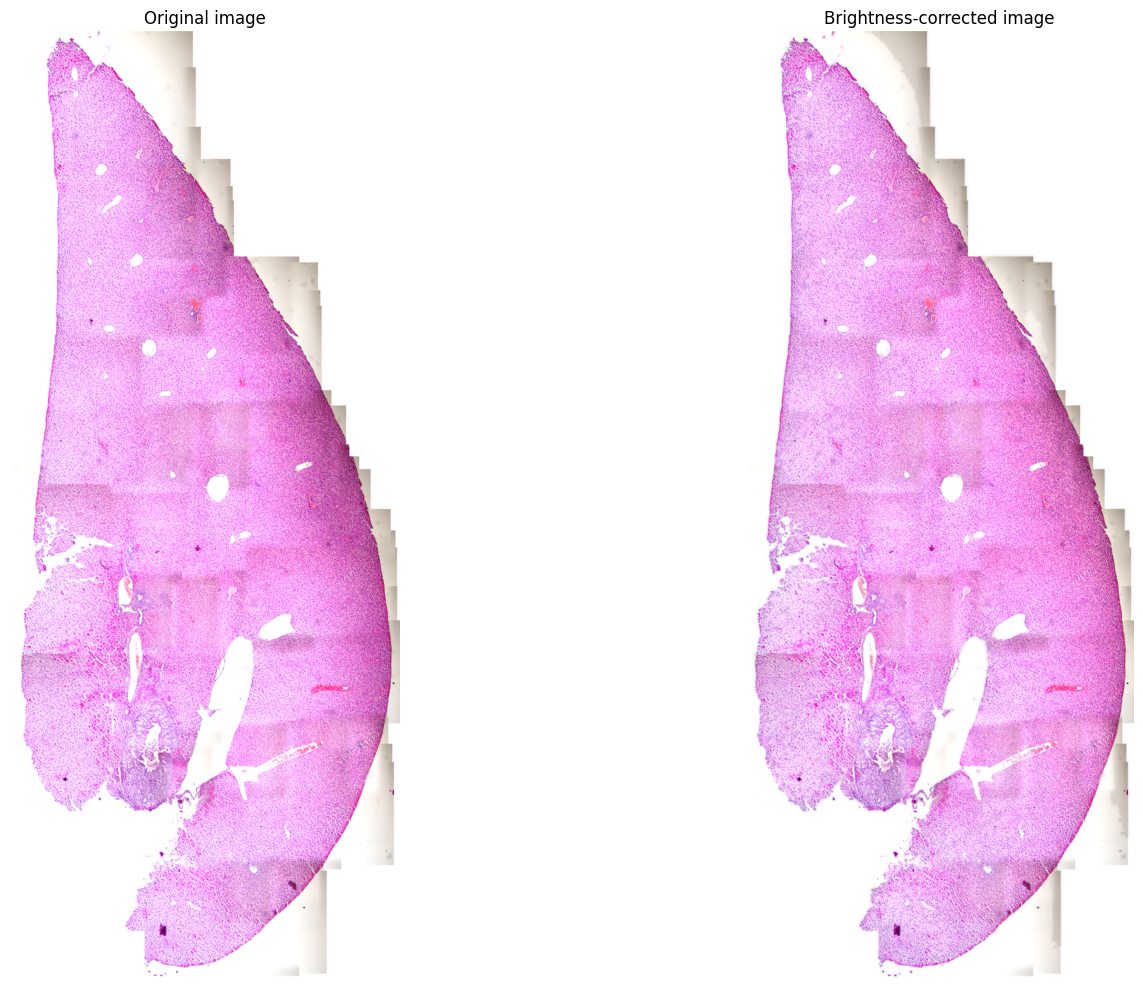

In [99]:
show_bgr_pair(
    bgr,
    corrected_bgr,
    original_title="Original image",
    corrected_title="Brightness-corrected image"
)

# Machenco normalization

In [147]:
import numpy as np
from pathlib import Path
import torch
import torchstain
from PIL import Image
from torchvision import transforms
from torchvision.transforms import ToTensor
from torch_staintools.normalizer import NormalizerBuilder

import matplotlib.pyplot as plt

REFERENCE_PATH =  Path.cwd().parent / "full_view" / "Balbc_10x_2k_ref.tif"   # clean H&E reference image
SOURCE_PATH =  Path.cwd().parent / "full_view" / "Balbc_10x_2k_corrected_fiji.tif"
OUTPUT_PATH =  Path.cwd().parent / "full_view" / "slide_macenko_normalized.tif"

reference_rgb = np.asarray(Image.open(REFERENCE_PATH).convert("RGB"))
source_rgb = np.asarray(Image.open(SOURCE_PATH).convert("RGB"))

print("Reference:", reference_rgb.shape, reference_rgb.dtype)
print("Source:", source_rgb.shape, source_rgb.dtype)

ModuleNotFoundError: No module named 'torchvision.transforms.functional'; 'torchvision.transforms' is not a package

In [138]:
reference_rgb = np.asarray(
    Image.open(REFERENCE_PATH).convert("RGB")
)

source_rgb = np.asarray(
    Image.open(SOURCE_PATH).convert("RGB")
)

print("Reference:", reference_rgb.shape, reference_rgb.dtype,
      reference_rgb.min(), reference_rgb.max())

print("Source:", source_rgb.shape, source_rgb.dtype,
      source_rgb.min(), source_rgb.max())

Reference: (512, 512, 3) uint8 0 255
Source: (4306, 1772, 3) uint8 0 255


In [140]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cpu


In [141]:
to_tensor = ToTensor()

reference_tensor = to_tensor(reference_rgb).unsqueeze(0).float().to(device)
source_tensor = to_tensor(source_rgb).unsqueeze(0).float().to(device)

print("Reference tensor:", reference_tensor.shape,
      reference_tensor.dtype,
      reference_tensor.min().item(),
      reference_tensor.max().item())

print("Source tensor:", source_tensor.shape,
      source_tensor.dtype,
      source_tensor.min().item(),
      source_tensor.max().item())

Reference tensor: torch.Size([1, 512, 512, 3]) torch.float32 0.0 1.0
Source tensor: torch.Size([1, 4306, 1772, 3]) torch.float32 0.0 1.0


In [143]:
normalizer = NormalizerBuilder.build(
    "macenko",
    concentration_method="ista",
    use_cache=False
).to(device)

normalizer.fit(reference_tensor)

with torch.no_grad():
    normalized_tensor = normalizer(source_tensor)

print("Output tensor:", normalized_tensor.shape)
print("Output range:",
      normalized_tensor.min().item(),
      normalized_tensor.max().item())

NameError: name 'NormalizerBuilder' is not defined

In [ ]:
normalized_rgb = (
    normalized_tensor
    .squeeze(0)             # C, H, W
    .permute(1, 2, 0)       # H, W, C
    .clamp(0, 1)
    .mul(255)
    .byte()
    .cpu()
    .numpy()
)

print("Final RGB shape:", normalized_rgb.shape)
print("Final RGB dtype:", normalized_rgb.dtype)

assert normalized_rgb.shape == (4306, 1772, 3)
assert normalized_rgb.dtype == np.uint8

Image.fromarray(normalized_rgb, mode="RGB").save(
    OUTPUT_PATH,
    compression="tiff_deflate"
)

print(f"Saved: {OUTPUT_PATH}")